## Импорт библиотек

In [1]:
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

## Описание данных

Датасет: Pima Indians Diabetes Database

Данный датасет предназначен для диагностического прогнозирования наличия или отсутствия диабета на основе медицинских показателей пациентов

Количество наблюдений: 768

Количество признаков: 9

Целевая переменная: Outcome

Все наблюдения в датасете относятся к женщинам в возрасте от 21 года и старше, принадлежащим к популяции индейцев пима


| Признак | Описание |
|----------|----------|
| Pregnancies | Количество беременностей |
| Glucose | Концентрация глюкозы в плазме крови через 2 часа при пероральном глюкозотолерантном тесте |
| BloodPressure | Диастолическое артериальное давление (мм рт. ст.) |
| SkinThickness | Толщина кожной складки над трицепсом (мм) |
| Insulin | Уровень инсулина в сыворотке крови через 2 часа (мкЕд/мл) |
| BMI | Индекс массы тела (вес в кг/(рост в м)²) |
| DiabetesPedigreeFunction | Относительный индекс наследственной предрасположенности к диабету |
| Age | Возраст (годы) |
| Outcome | Наличие диабета (0 — нет, 1 — да) |

Источник датасета: https://www.kaggle.com/datasets/uciml/pima-indians-diabetes-database

## Структура данных

In [2]:
diabetes_df = pd.read_csv("diabetes.csv")
diabetes_df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [3]:
diabetes_df.shape

(768, 9)

In [4]:
diabetes_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [5]:
# Проверим количество полных дубликатов
diabetes_df.duplicated().sum()

np.int64(0)

In [6]:
# Дополнительно проверим пропуски
diabetes_df.isna().sum()

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

In [7]:
# Проверим значения по каждому признаку
diabetes_df.describe().T

,count,mean,std,min,25%,50%,75%,max
Pregnancies,768.0,3.845052,3.369578,0.000,1.00000,3.0000,6.00000,17.00
Glucose,768.0,120.894531,31.972618,0.000,99.00000,117.0000,140.25000,199.00
BloodPressure,768.0,69.105469,19.355807,0.000,62.00000,72.0000,80.00000,122.00
SkinThickness,768.0,20.536458,15.952218,0.000,0.00000,23.0000,32.00000,99.00
Insulin,768.0,79.799479,115.244002,0.000,0.00000,30.5000,127.25000,846.00
BMI,768.0,31.992578,7.884160,0.000,27.30000,32.0000,36.60000,67.10
DiabetesPedigreeFunction,768.0,0.471876,0.331329,0.078,0.24375,0.3725,0.62625,2.42
Age,768.0,33.240885,11.760232,21.000,24.00000,29.0000,41.00000,81.00
Outcome,768.0,0.348958,0.476951,0.000,0.00000,0.0000,1.00000,1.00


**Вывод:**

В исследуемом датасете содержится 768 наблюдений, 9 признаков, включая целевую переменную. Восемь признаков являются количественными. Из них признак Pregnancies является дискретным, остальные признаки (Glucose, BloodPressure, SkinThickness, Insulin, BMI, DiabetesPedigreeFunction, Age) - непрерывными количественными. Целевая переменная Outcome является категориальной бинарной, где 0 - отсутствие заболевания, 1 - его наличие. Номинальные признаки отсутствуют.

В рамках первичного анализа данных была проведена проверка на соответствие типов данных их содержанию. Все количественные признаки представлены в числовом формате int64 и float64, целевая переменная в формате int64. Признаки Pregnancies, Glucose, BloodPressure, SkinThickness, Insulin, Age, Outcome представлены целочисленными значениями и соответствуют типу int64. Признаки BMI и DiabetesPedigreeFunction представлены числами с плавающей точкой, поэтому их тип данных соотвествует float64. Некорректные типы данных отсутствуют. Следовательно, преобразование типов данных не требуется.

Полные дубликаты строк в датасете отсутствуют. Следовательно, удаление дубликатов не требуется. 

По результатам применения метода info() и подсчета нулевых значений, пропуски не были выявлены. Но после рассчета описательных статистик по переменным можно заметить, что минимальные значения для Glucose, BloodPressure, SkinThickness, Insulin, BMI равны нулю, что является невозможным, так как мы рассматриваем такие признаки, которые отражают физиологическое состояние человека и они не могут принимать нулевые значения. При этом, значения признака Pregnancies может быть и нулевыми, что будет означать отсутствие беременностей. Поэтому далее проанализируем нулевые значения.


### Анализ нулевых значений

In [8]:
# Создадим список из признаков, которые содержали нехарактерные для них нулевые значения
zero_min_vals_features = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']

In [9]:
# Подсчитаем количество нулевых значений в датасете для признаков Glucose, BloodPressure, SkinThickness, Insulin, BMI
null_vals_cnt = (
    (diabetes_df[zero_min_vals_features] == 0)
        .sum()
        .sort_values(ascending=False)
    )

# Посчитаем процент нулевых значений от общего числа наблюдений
null_vals_pct = round(null_vals_cnt / len(diabetes_df) * 100, 2)

In [10]:
# Соберем значения, рассчитанные выше в единый DataFrame
pd.DataFrame({'missing_count': null_vals_cnt, 'missing_percent': null_vals_pct})

,missing_count,missing_percent
Insulin,374,48.70
SkinThickness,227,29.56
BloodPressure,35,4.56
BMI,11,1.43
Glucose,5,0.65


**Вывод:**

В данных выявлено значительное количество нулевых значений. Наибольший процент нулевых значений наблюдается у признаков Insulin (48.7%) и SkinThickness (29.6%). Можно предположить, что нулевые значения означают отсутствие измерений. 

Учитывая, что датасет содержит небольшое количество наблюдений, удаление наблюдений может привести к потере существенной части данных. Поскольку в дальнейшем данные будут использоваться для построения моделей машинного обучения, обработка пропусков должна выполняться после разделения выборки на обучающую и тестовую. Это необходимо для предотвращения утечки данных и обеспечения корректной оценки качества модели.

Таким образом, импутация будет реализована на этапе подготовки данных к моделированию. В качестве одного из возможных методов заполнения пропусков предлагается заменить нулевые значения медианными значениями соответствующих признаков с учетом категории целевой переменной. 

## Анализ распределений признаков

### Целевая переменная Outcome

In [11]:
# Посчитаем количество уникальных значений целевого признака Outcome
outcome_cnt = diabetes_df['Outcome'].value_counts()

# Посчитаем процент каждой категории в общем количестве наблюдений
outcome_pct = round(diabetes_df['Outcome'].value_counts(normalize=True) * 100, 2)

In [12]:
# Объединим рассчеты по признаку Outcome в единый датафрейм
pd.DataFrame({'outcome_count': outcome_cnt, 'outcome_percent': outcome_pct})

,outcome_count,outcome_percent
Outcome,,
0,500,65.1
1,268,34.9


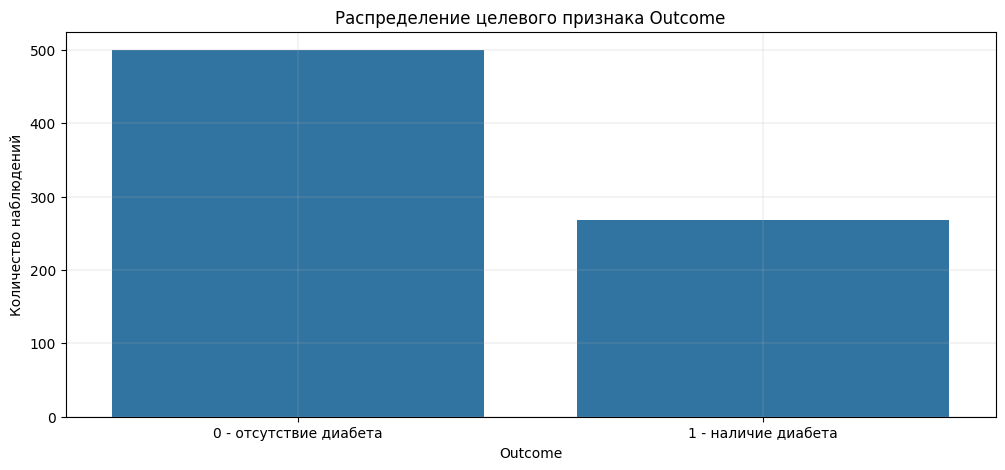

In [13]:
plt.figure(figsize=(12, 5))
sns.countplot(data=diabetes_df, x='Outcome')
plt.title('Распределение целевого признака Outcome')
plt.xlabel('Outcome')
plt.ylabel('Количество наблюдений')
plt.xticks([0, 1], ['0 - отсутствие диабета', '1 - наличие диабета'])
plt.grid(linewidth=0.2)
plt.show()

**Вывод по целевому признаку Outcome:**

Исходя из анализа целевой переменной, можно сделать вывод о том, что количество пациентов без диагностированного диабета превышает количество пациентов с диабетом. Эти значения распределены следующим образом: 
- для категории 0 (нет диабета) - 500 наблюдений, что составляет 65.1% от общего числа наблюдений, 
- для категории 1 (есть диабет) - 268 наблюдений, что составляет 34.9% от общего числа наблюдений.

Таким образом, наблюдается дисбаланс классов. 

### Описательные статистики признаков

In [14]:
diabetes_df.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


**Вывод:**

Отрицательные значения отсутствуют. Большинство максимальных значений являются возможными. За исключением максимальных показателей для признаков SkinThickness (99) и Insulin (846). Данные значения являются сомнительными и возможно отражают выбросы, ошибки в измерениях или особый клинический случай. Далее повторно их рассмотрим в разделе, посвященному анализу выбросов. А также рассмотрим распределения во каждому признаку.

### Дискретный признак Pregnancies

In [15]:
# Посчитаем количество уникальных значений признака Pregnancies
diabetes_df['Pregnancies'].value_counts()

Pregnancies
1     135
0     111
2     103
3      75
4      68
5      57
6      50
7      45
8      38
9      28
10     24
11     11
13     10
12      9
14      2
15      1
17      1
Name: count, dtype: int64

In [16]:
# Рассчитаем значение ассиметрии
print(round(diabetes_df['Pregnancies'].skew(), 2))

0.9


Значение асимметрии положительное (0.9), значит данные имеют правостороннюю асимметрию.

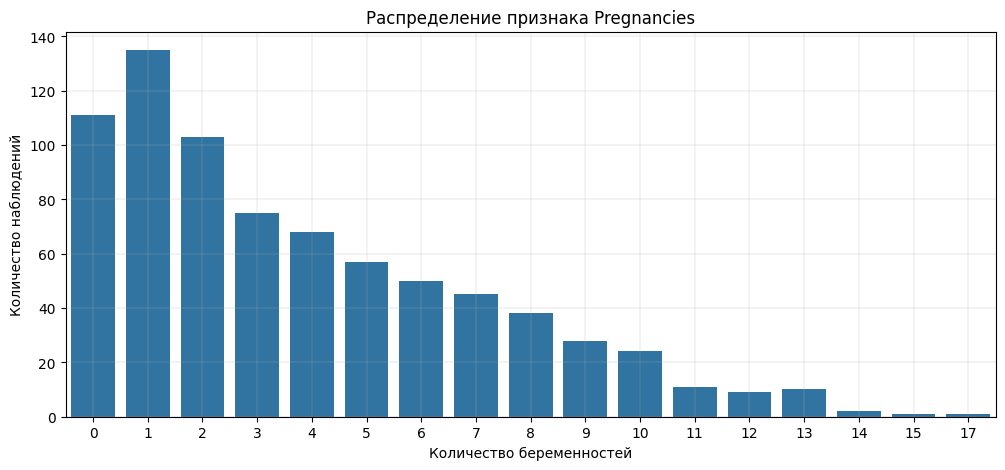

In [17]:
plt.figure(figsize=(12, 5))
sns.countplot(data=diabetes_df, x='Pregnancies')
plt.title('Распределение признака Pregnancies')
plt.xlabel('Количество беременностей')
plt.ylabel('Количество наблюдений')
plt.grid(linewidth=0.2)
plt.show()

**Вывод по признаку Pregnancies:**

Признак Pregnancies принимает значений от 0 до 17. При этом, большая часть наблюдений лежит в диапозоне от 0 до 2. Распределение имеет выраженную правостороннюю асимметрию. Данное наблюдение является ожидаемым, так как с увеличением количества беременностей, уменьшается число наблюдений.

### Непрерывные признаки

In [18]:
continues_features = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age']

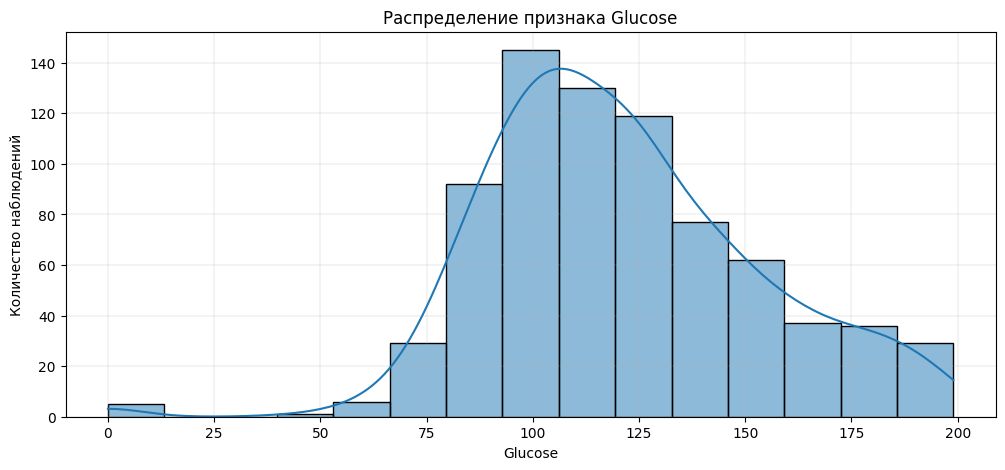

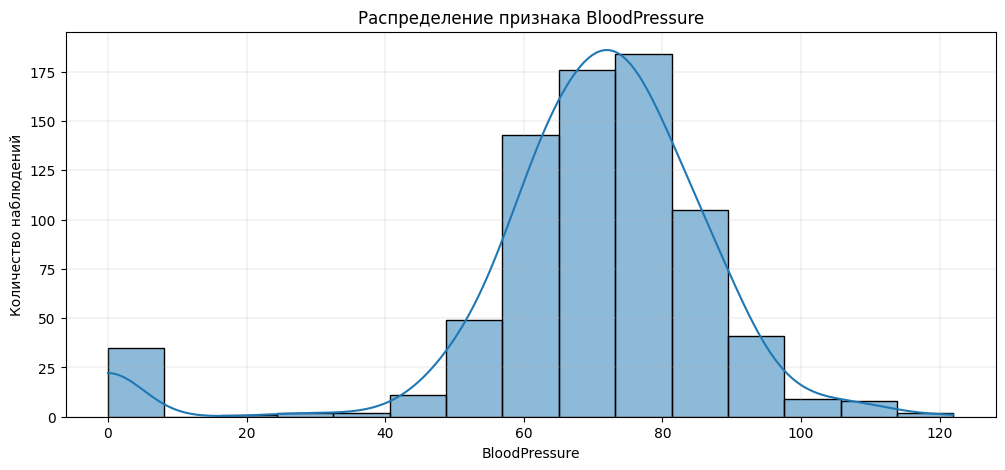

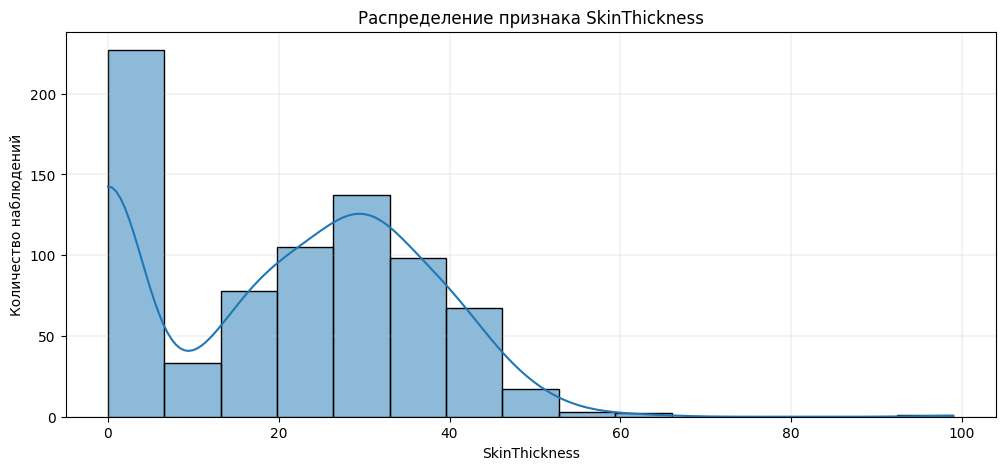

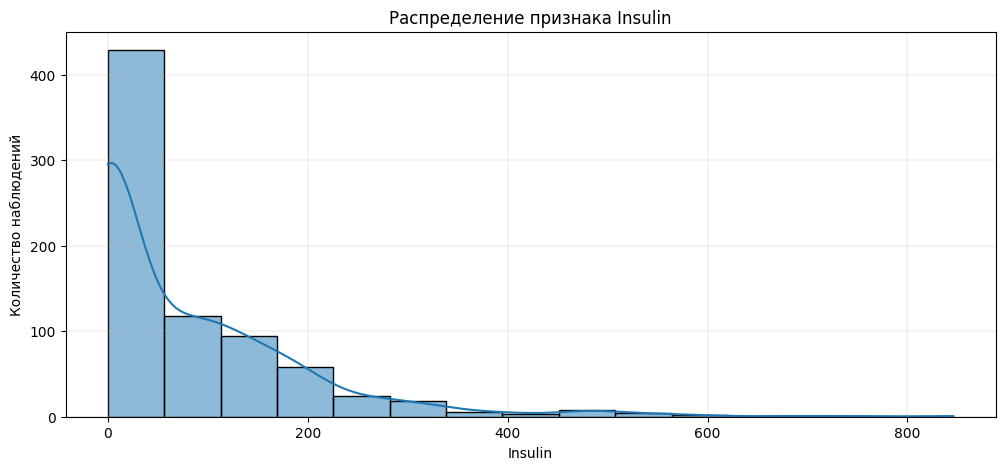

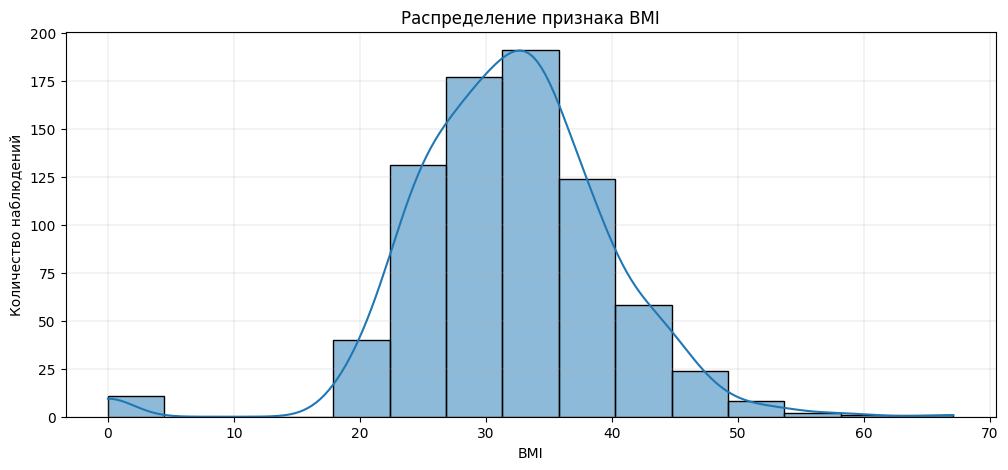

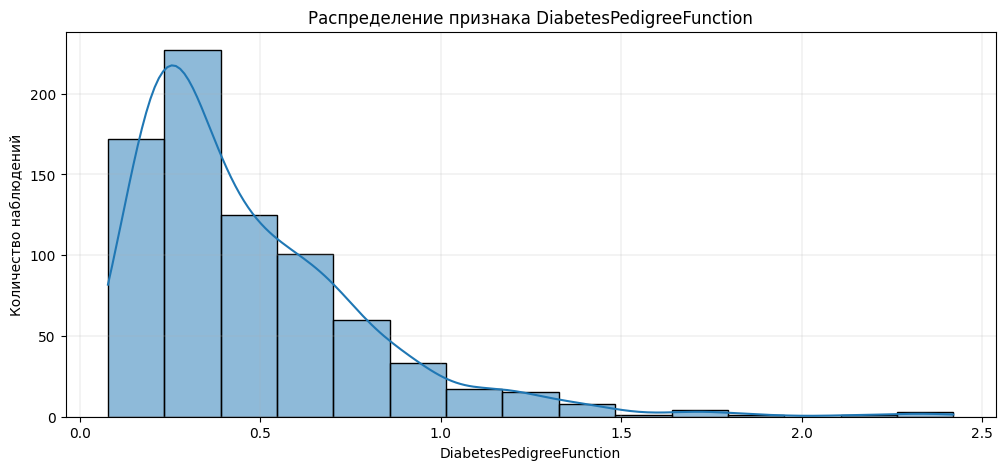

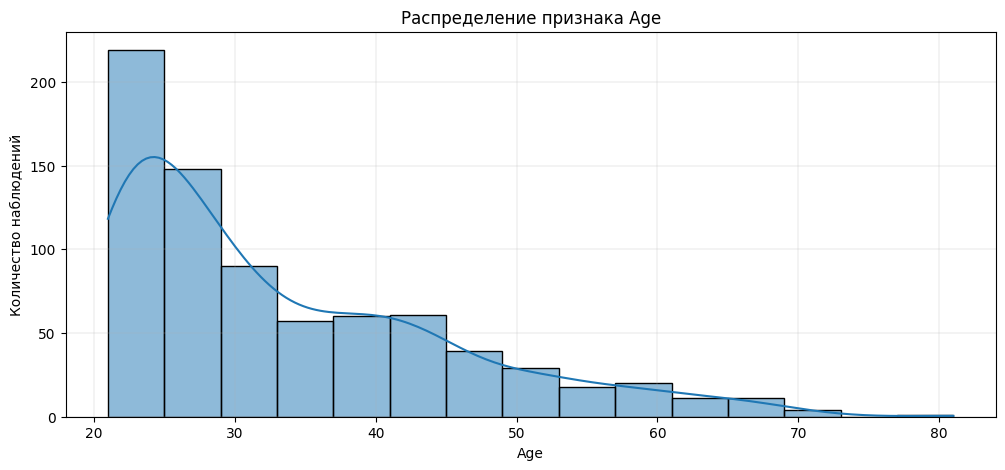

In [19]:
for feature in continues_features:
    plt.figure(figsize=(12, 5))
    sns.histplot(data=diabetes_df[feature], bins=15, kde=True)
    plt.title(f'Распределение признака {feature}')
    plt.xlabel(feature)
    plt.ylabel('Количество наблюдений')
    plt.grid(linewidth=0.2)
    plt.show()

**Вывод:**

Наиболее выраженная правосторонняя асимметрия у признаков:
- Insulin, 
- DiabetesPedigreeFunction. 

Это характерно для DiabetesPedigreeFunction, тк есть редкие большие значения и большинство значений небольшие (что можно интерпретировать как низкую наследственную предраспположенность).

У признака Age умеренная правосторонняя симметрия, так как большинство наблюдений о пациентах до 30 лет.

Учитывая наличие пропусков, распределение близкое к нормальному наблюдается у BloodPressure.

## Анализ выбросов

In [20]:
# Отберем все признаки, за исключением целевого
feature_columns = diabetes_df.columns.drop('Outcome')
feature_columns

Index(['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin',
       'BMI', 'DiabetesPedigreeFunction', 'Age'],
      dtype='object')

In [21]:
# Посчитаем количество выбросов для каждого признака с учетом категории целевой переменной
rows = []

group_sizes = diabetes_df['Outcome'].value_counts().sort_index()

for col in feature_columns:
    for outcome_val in sorted(diabetes_df['Outcome'].unique()):
        group = diabetes_df[diabetes_df['Outcome'] == outcome_val][col]
        Q1 = group.quantile(0.25)
        Q3 = group.quantile(0.75)
        IQR = Q3 - Q1

        lower = Q1 - 1.5 * IQR
        upper = Q3 + 1.5 * IQR
        outliers = group[(group < lower) | (group > upper)]
        outliers_cnt = len(outliers)
        outliers_pct = round(outliers_cnt / group_sizes[outcome_val] * 100, 2)

        rows.append([col, outcome_val, outliers_cnt, outliers_pct])

outliers_df = pd.DataFrame(rows, columns=['feature', 'Outcome', 'count', 'percent'])
outliers_df

,feature,Outcome,count,percent
0,Pregnancies,0,10,2.00
1,Pregnancies,1,0,0.00
2,Glucose,0,14,2.80
3,Glucose,1,2,0.75
4,BloodPressure,0,26,5.20
5,BloodPressure,1,22,8.21
6,SkinThickness,0,0,0.00
7,SkinThickness,1,1,0.37
8,Insulin,0,26,5.20
9,Insulin,1,12,4.48


Описательная статистика для признака Pregnancies:
   Outcome      mean       std  min   25%  50%  75%   max
0        0  3.298000  3.017185  0.0  1.00  2.0  5.0  13.0
1        1  4.865672  3.741239  0.0  1.75  4.0  8.0  17.0

Количество и процент выбросов для признака Pregnancies:
   Outcome  count  percent
0        0     10      2.0
1        1      0      0.0


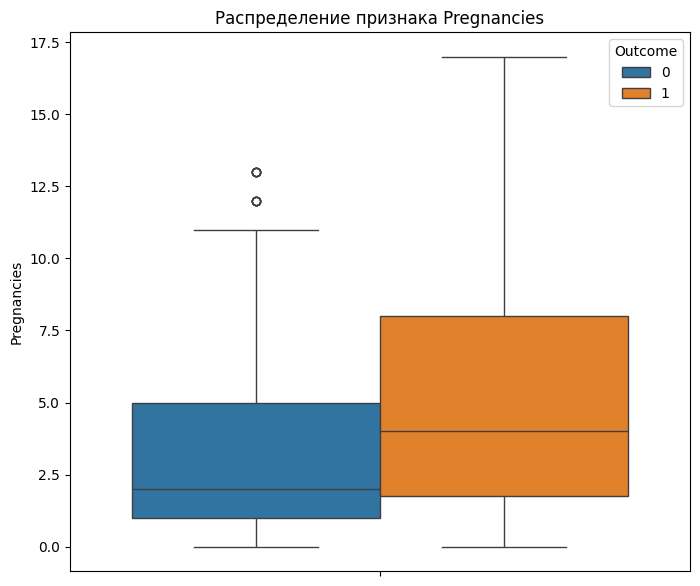

Описательная статистика для признака Glucose:
   Outcome        mean        std  min    25%    50%    75%    max
0        0  109.980000  26.141200  0.0   93.0  107.0  125.0  197.0
1        1  141.257463  31.939622  0.0  119.0  140.0  167.0  199.0

Количество и процент выбросов для признака Glucose:
   Outcome  count  percent
0        0     14     2.80
1        1      2     0.75


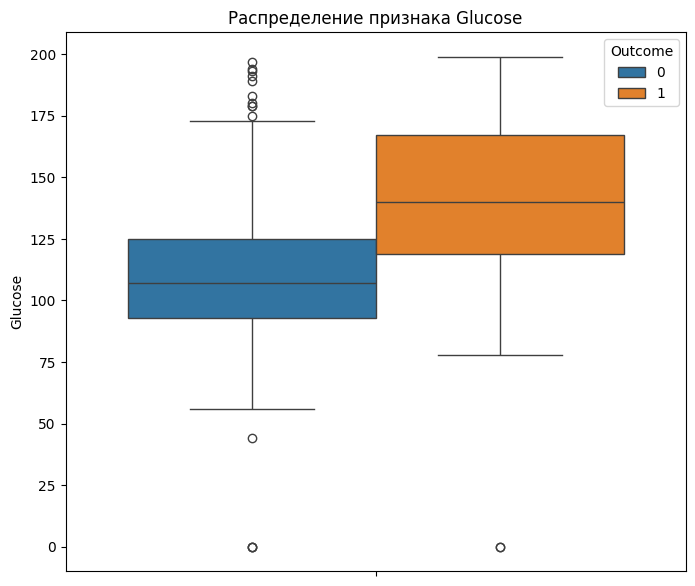

Описательная статистика для признака BloodPressure:
   Outcome       mean        std  min   25%   50%   75%    max
0        0  68.184000  18.063075  0.0  62.0  70.0  78.0  122.0
1        1  70.824627  21.491812  0.0  66.0  74.0  82.0  114.0

Количество и процент выбросов для признака BloodPressure:
   Outcome  count  percent
0        0     26     5.20
1        1     22     8.21


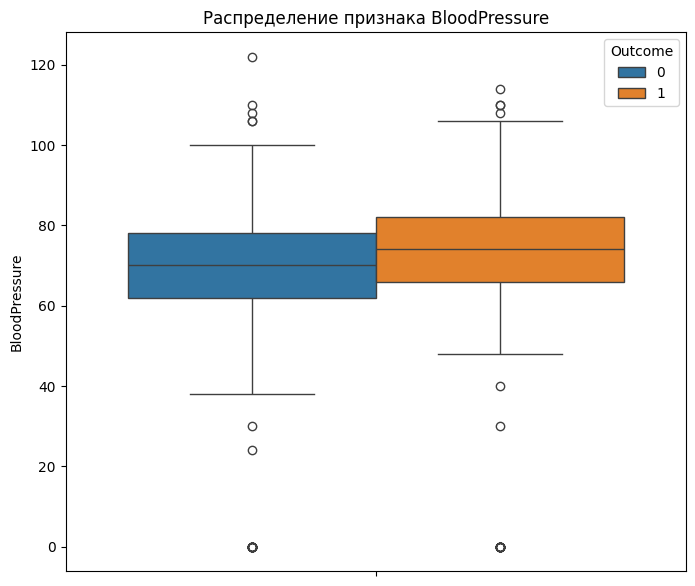

Описательная статистика для признака SkinThickness:
   Outcome       mean        std  min  25%   50%   75%   max
0        0  19.664000  14.889947  0.0  0.0  21.0  31.0  60.0
1        1  22.164179  17.679711  0.0  0.0  27.0  36.0  99.0

Количество и процент выбросов для признака SkinThickness:
   Outcome  count  percent
0        0      0     0.00
1        1      1     0.37


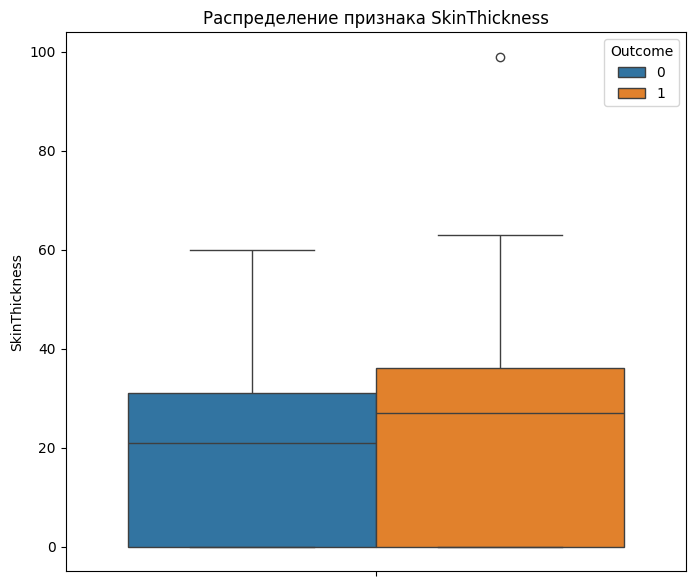

Описательная статистика для признака Insulin:
   Outcome        mean         std  min  25%   50%     75%    max
0        0   68.792000   98.865289  0.0  0.0  39.0  105.00  744.0
1        1  100.335821  138.689125  0.0  0.0   0.0  167.25  846.0

Количество и процент выбросов для признака Insulin:
   Outcome  count  percent
0        0     26     5.20
1        1     12     4.48


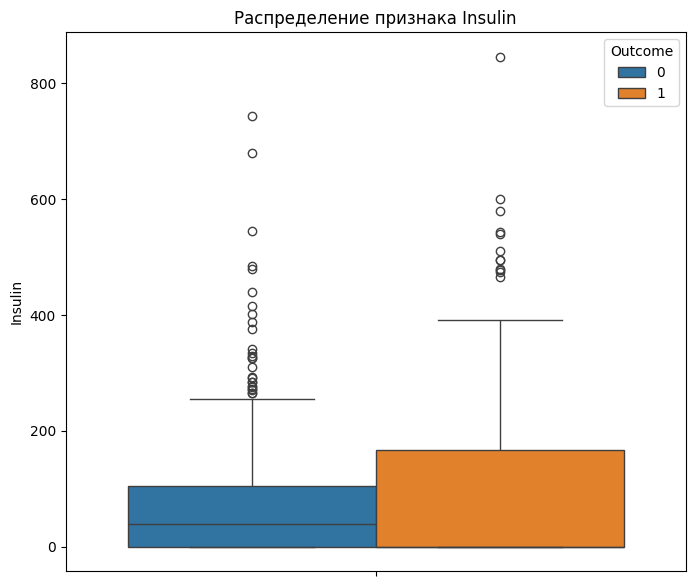

Описательная статистика для признака BMI:
   Outcome       mean       std  min   25%    50%     75%   max
0        0  30.304200  7.689855  0.0  25.4  30.05  35.300  57.3
1        1  35.142537  7.262967  0.0  30.8  34.25  38.775  67.1

Количество и процент выбросов для признака BMI:
   Outcome  count  percent
0        0     11     2.20
1        1      8     2.99


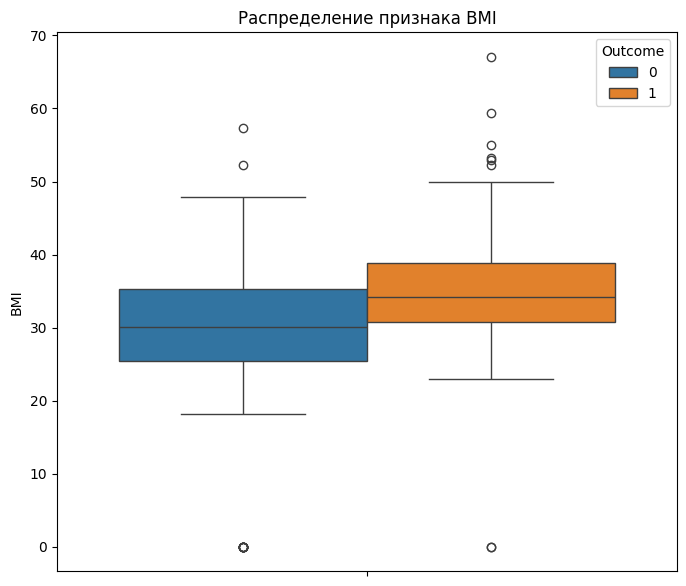

Описательная статистика для признака DiabetesPedigreeFunction:
   Outcome      mean       std    min      25%    50%      75%    max
0        0  0.429734  0.299085  0.078  0.22975  0.336  0.56175  2.329
1        1  0.550500  0.372354  0.088  0.26250  0.449  0.72800  2.420

Количество и процент выбросов для признака DiabetesPedigreeFunction:
   Outcome  count  percent
0        0     20     4.00
1        1      4     1.49


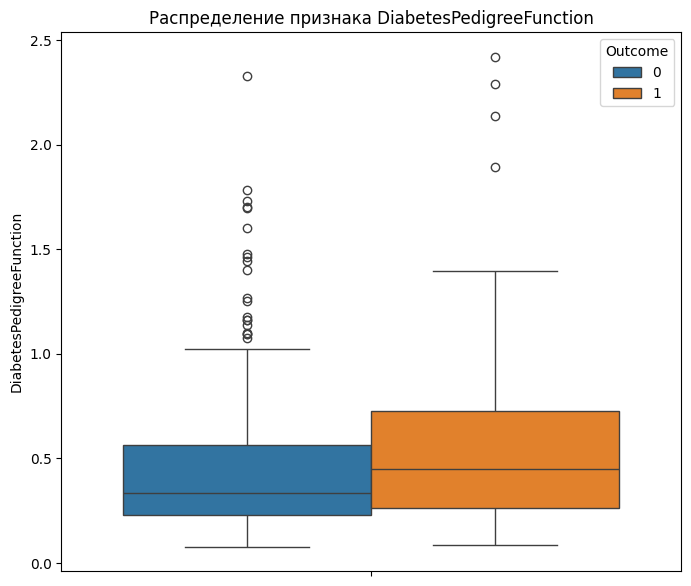

Описательная статистика для признака Age:
   Outcome       mean        std   min   25%   50%   75%   max
0        0  31.190000  11.667655  21.0  23.0  27.0  37.0  81.0
1        1  37.067164  10.968254  21.0  28.0  36.0  44.0  70.0

Количество и процент выбросов для признака Age:
   Outcome  count  percent
0        0     24     4.80
1        1      1     0.37


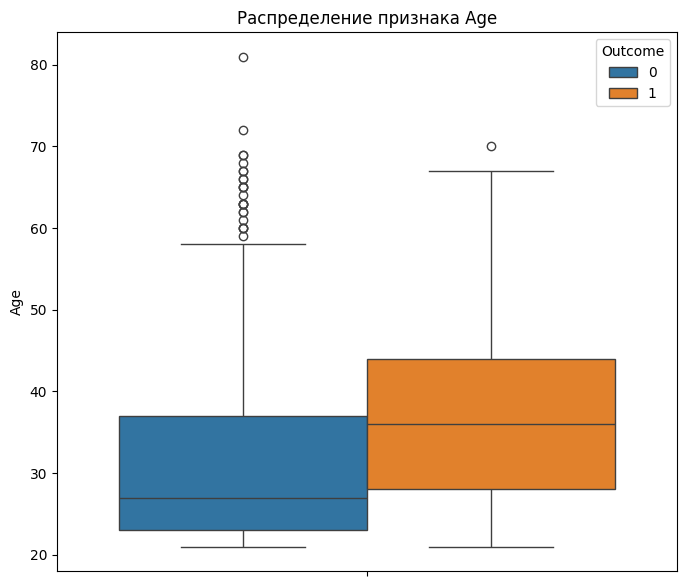

In [22]:
# Построим диаграммы размаха (boxplot) для каждого признака с разделением по категориям целевой переменной
for feature in feature_columns:
    feature_description = (
        diabetes_df
        .groupby('Outcome')[feature]
        .describe()[['mean', 'std', 'min', '25%', '50%', '75%', 'max']]
        .reset_index()
    )
    print(f'Описательная статистика для признака {feature}:')
    print(feature_description)
    print(f'\nКоличество и процент выбросов для признака {feature}:')
    print(outliers_df[outliers_df['feature'] == feature][['Outcome', 'count', 'percent']].reset_index(drop=True))

    plt.figure(figsize=(8, 7))
    sns.boxplot(data=diabetes_df, y=feature, hue='Outcome')
    plt.title(f'Распределение признака {feature}')
    plt.show()

**Вывод:**

В результате анализа признаков на наличие выбросов, можно сказать о том, что наибольшее их количество наблюдается для признака BloodPressure (26 значений для пациентов без диабета и 22 значения для пациентов с диагностированным диабетом), Insulin (26 значений для пациентов без диабета и 12 для пациентов с диагностированным диабетом). Также стоит отметить, что признак Insulin содержит большое количество нулевых значений. 
На этапе анализа описательных статистик было отмечено, что для данного признака содержится максимальное значение 846, после построения боксплотов, можно отметить, что экстремальные значения не являются единичными, составляют небольшой процент выборки, следовательно, вероятно, относятся к тяжелым клиническим случаям и не являются явно некорректными. Что касается признака SkinThickness, то в нем было отмечено максимальное значение 99, и после анализа графиков и информации о выбросах, можно отметить, что это относится к единичному выбросу, что в свою очередь не позволяет однозначно его трактовать как ошибочное. Учитывая клиническую природу данных, это значение может быть аномально высоким показателем. 

Для подсчета количества выбросов по каждому признаку использовался метод межквартильного размаха (IQR): значения выходящие за пределы [Q1-1.5*IQR, Q3+ 1.5 * IQR] относились к выбросам. Учитывая тот факт, что эти данные относятся к медицинским показателям, эти значения могут соответствовать реальным случаям. Датасет содержит небольшое количество наблюдений (768) и было принято решение не удалять выбросы, чтобы не потерять значимое количество информации. 
Дополнительно следует отметить, что высокая доля пропусков по признаку Insulin, особенности его распределения и выбросы требуют дальнейшего анализа. На этапе построения моделей планируется оценить его влияние и далее принять обоснованное решение о его использовании. 

## Корреляция числовых признаков

### Матрица корреляций между признаками

In [23]:
# Матрица корреляций числовых признаков
correlation_matrix = diabetes_df[feature_columns].corr()
correlation_matrix

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age
Pregnancies,1.000000,0.129459,0.141282,-0.081672,-0.073535,0.017683,-0.033523,0.544341
Glucose,0.129459,1.000000,0.152590,0.057328,0.331357,0.221071,0.137337,0.263514
BloodPressure,0.141282,0.152590,1.000000,0.207371,0.088933,0.281805,0.041265,0.239528
SkinThickness,-0.081672,0.057328,0.207371,1.000000,0.436783,0.392573,0.183928,-0.113970
Insulin,-0.073535,0.331357,0.088933,0.436783,1.000000,0.197859,0.185071,-0.042163
BMI,0.017683,0.221071,0.281805,0.392573,0.197859,1.000000,0.140647,0.036242
DiabetesPedigreeFunction,-0.033523,0.137337,0.041265,0.183928,0.185071,0.140647,1.000000,0.033561
Age,0.544341,0.263514,0.239528,-0.113970,-0.042163,0.036242,0.033561,1.000000


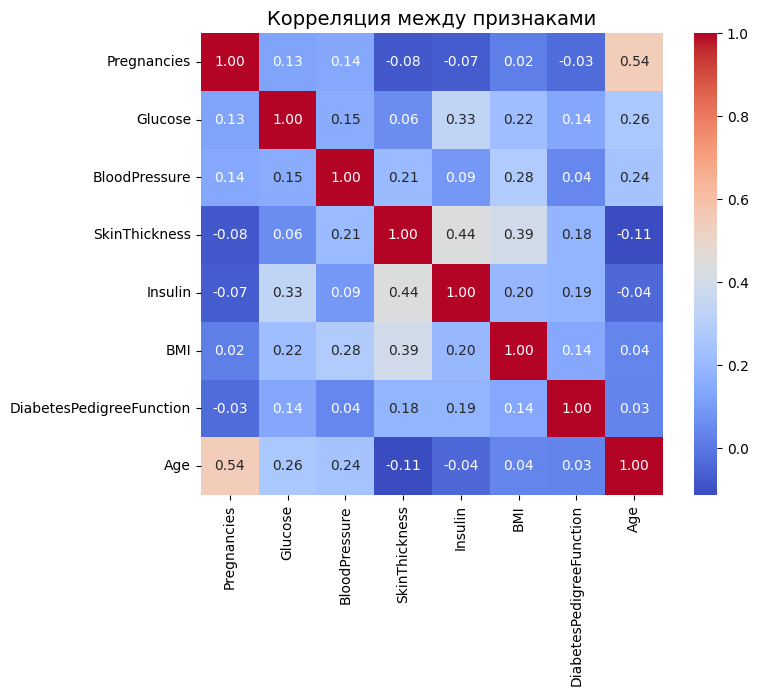

In [24]:
plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", square=True)
plt.title('Корреляция между признаками', fontsize=14)
plt.show()

**Вывод:**

По результатам анализа корреляции между признаками наибольшая положительная связь установлена между признаками Age и Pregnancies (0.54), Insulin и SkinThickness (0.44), BMI и SkinThickness (0.39), Insulin и Glucose(0.33). Это логически объяснимо: чем выше индекс массы тела, тем больше толщина кожной складки; чем выше возраст, тем вероятнее увеличение числа беременностей; повышение уровня глюкозы в крови сопровождается выбросом инсулина. Взаимосвязь между Insulin и SkinThickness (0.44) может быть обоснована физиологически, но также может быть искажена наличием нулевых значений. 

При этом значения корреляции не превышают 0.7, что говорит об отсутствии выраженной мультиколлинеарности между признаками. 

### Корреляция с целевой переменной Outcome

In [25]:
# Рассчитаем матрицу корреляций между целевой переменной и признаками
correlation_matrix_outcome = (
    diabetes_df.corr()['Outcome']
    .drop('Outcome')
    .sort_values(ascending=False)
    .to_frame()
)
correlation_matrix_outcome

,Outcome
Glucose,0.466581
BMI,0.292695
Age,0.238356
Pregnancies,0.221898
DiabetesPedigreeFunction,0.173844
Insulin,0.130548
SkinThickness,0.074752
BloodPressure,0.065068


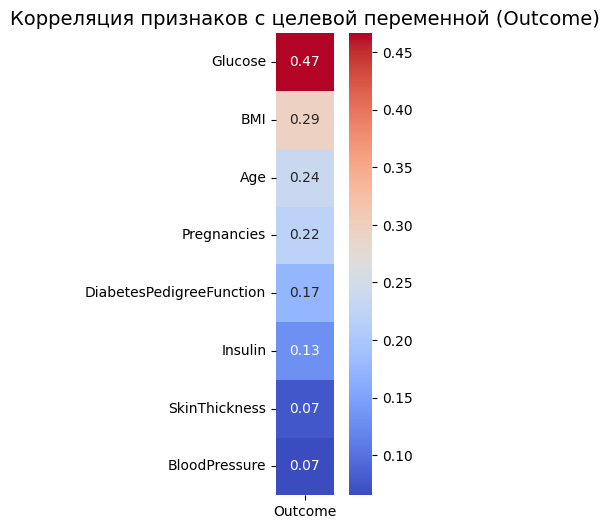

In [26]:
plt.figure(figsize=(4, 6))
sns.heatmap(correlation_matrix_outcome, annot=True, cmap='coolwarm', fmt=".2f", square=True)
plt.title('Корреляция признаков с целевой переменной (Outcome)', fontsize=14)
plt.yticks(rotation=0)
plt.show()

**Вывод:**

По результатам анализа корреляции между признаками и целевой переменной Outcome наибольшая положительная корреляция с целевой переменной заметна у признака Glucose (0.47). Умеренная положительная связь выявлена для признака BMI. Остальные признаки демонстрируют слабую связь с целевой переменной. Для оценки корреляции использовалась Шкала Чеддока.

### Cравнение признаков по классам (матрица попарных зависимостей)

In [27]:
# Отберем признаки с наиболее выраженной корреляцией с целевой переменной
selected_features = ['Glucose', 'BMI', 'Age', 'Pregnancies', 'Outcome']

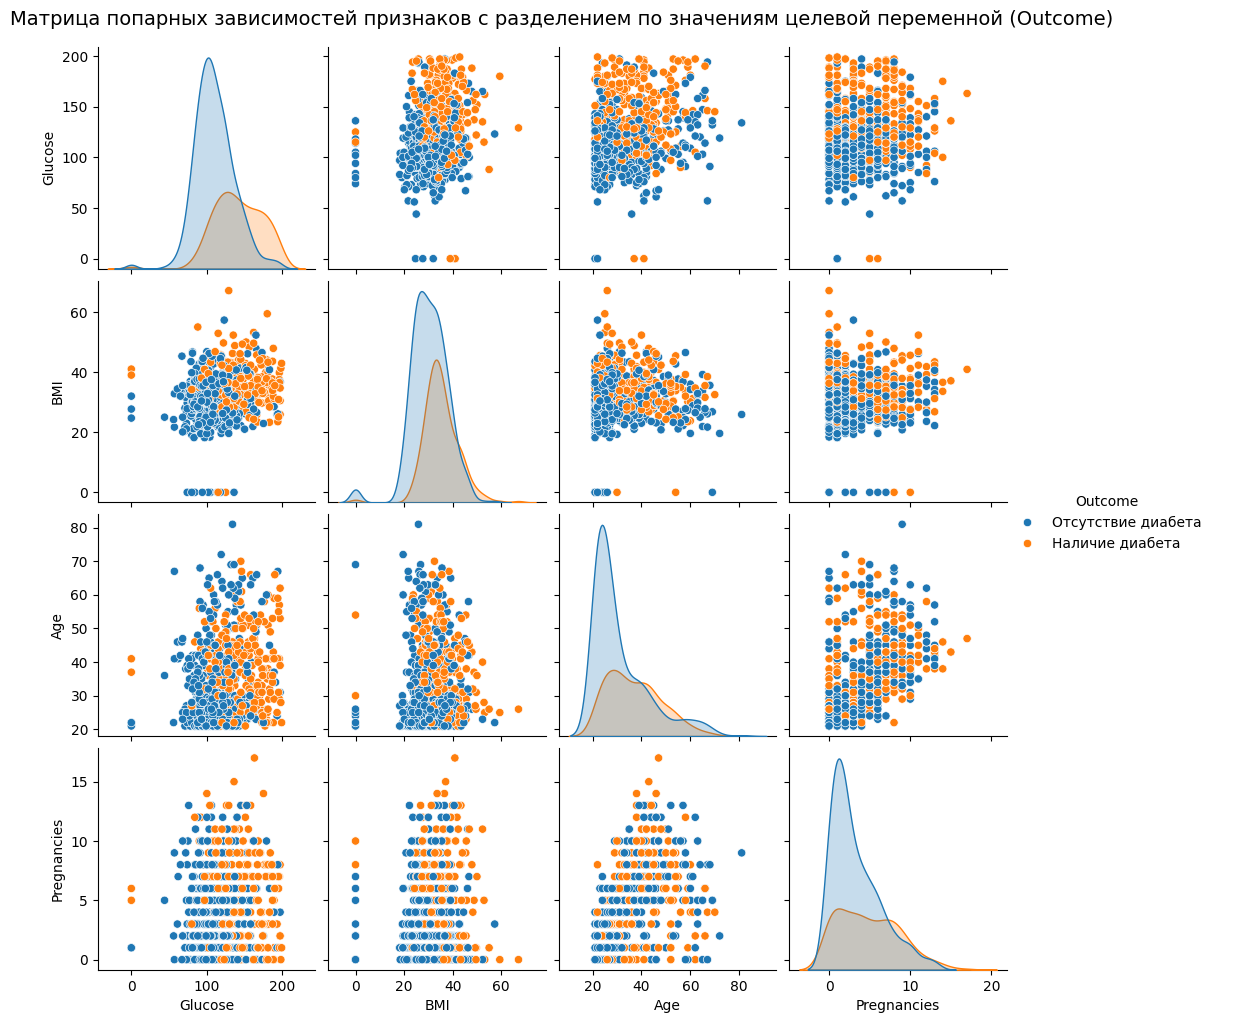

In [28]:
# Построим pairplot для признаков с наиболее выраженной корреляцией с целевой переменной 
# c разделением по значениям переменной (Outcome)
g = sns.pairplot(data=diabetes_df[selected_features], hue='Outcome')
g.figure.suptitle('Матрица попарных зависимостей признаков с разделением по значениям целевой переменной (Outcome)', y=1.02, fontsize=14)
g._legend.texts[0].set_text("Отсутствие диабета")
g._legend.texts[1].set_text("Наличие диабета")
g._legend.set_bbox_to_anchor((1.13, 0.5))
plt.show()

**Вывод:**

По результатам анализа попарных зависимостей признаков с разделением по значениям целевой переменной Outcome, можно отметить, что наибольшая визуальная разделимость классов наблюдается по признаку Glucose c признаками BMI, Age, Pregnancies. Для остальных комбинаций признаков классы значительно перекрываются.  

## Общий вывод по результатам исследовательского анализа датасета Pima Indians Diabetes Database

В ходе исследовательского анализа датасета Pima Indians Diabetes Database было установлено, что восемь признаков являются количественными, при этом признак Pregnancies относится к дискретным переменным, а остальные - к непрерывным. Номинальные признаки отсутствуют. Проверка типов данных показала их корректность, преобразование типов данных не потребовалось. 

По результатам анализа пропусков, были выявлены скрытые пропуски, представленные нулевыми значениями в таких признаках как: Glucose, BloodPressure, SkinThickness, Insulin, BMI. Наибольшая доля нулевых значений приходилась на признак Insulin (48.7%). Нулевые значения были проинтерпретированы как отсутствие измерений по данным показателям. В связи с небольшим количеством наблюдений, было решено не удалять пропущенные значения. Поскольку в дальнейшем данные будут использоваться для построения моделей машинного обучения, обработка пропусков должна выполняться после разделения выборки на обучающую и тестовую.

Анализ выбросов, выполненный по правилу 1.5 межквартильного размаха (IQR), показал, что наибольшее количество выбросов у признаков BloodPressure, Insulin. Учитывая небольшое количество наблюдений для датасета и клиническую природу данных, было принято решение не удалять такие значения. На следующих этапах после замены пропусков, следует проанализировать выбросы повторно и принять решение о дальнейшей обработке.

Анализ распределений показал, что у большинства признаков выражена асимметрия. Наиболее выраженная правосторонняя асимметрия у признаков Insulin и DiabetesPedigreeFunction. Поэтому на следующих этапах возможно потребуется log-трансформация. Распределение близкое к нормальному наблюдается у признака BloodPressure. Наблюдается дисбаланс классов в целевой переменной Outcome (500 наблюдений о пациентах без диабета, 268 наблюдений о пациентах с диагностированным диабетом)

Корреляционный анализ выявил наибольшую положительную связь между признаком Glucose и целевой переменной Outcome. Также умеренная положительная связь наблюдается у целевой переменной Outcome c признаком BMI. Между признаками не выявлено выраженной мультиколлинеарности. Наибольшая положительная связь установлена между признаками BMI и SkinThickness, Age и Pregnancies, Insulin и Glucose. По результатам визуализации попарных зависимостей признаков, было выявлено, что наибольшая визуальная разделимость классов наблюдается у признака Glucose. 

Таким образом, проведенный исследовательский анализ данных позволил изучить основные характеристики данных, оценить распределения и выбросы, а также определить признаки, оказывающие наибольшее влияние на целевую переменную. 